In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import numpy as np
from tkinter import Tk
from tkinter.filedialog import askopenfilename
from PIL import Image
import matplotlib.pyplot as plt


c:\users\mahesh pala\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\users\mahesh pala\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\users\mahesh pala\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
c

In [2]:
# CIFAR-10 class labels
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [3]:
# Build a simple CNN model architecture
def create_model():
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
    model.add(Conv2D(32, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))
    
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))
    
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))
    
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [4]:
# Train a model on CIFAR-10 if no pre-trained model exists
def train_model():
    (x_train, y_train), (x_test, y_test) = cifar10.load_data()
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0
    y_train = to_categorical(y_train, 10)
    y_test = to_categorical(y_test, 10)
    
    model = create_model()
    model.fit(x_train, y_train, batch_size=64, epochs=10, validation_data=(x_test, y_test))
    model.save('cifar10_model.h5')
    return model

In [5]:
# Load a pre-trained model if available; otherwise, train a new one.
try:
    model = load_model('cifar10_model.h5')
    print("Loaded pre-trained model.")
except Exception as e:
    print("Pre-trained model not found. Training a new model...")
    model = train_model()

Pre-trained model not found. Training a new model...
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Train on 50000 samples, validate on 10000 samples
Epoch 1/10
50000/50000 [==============================] - 48s 967us/sample - loss: 1.5990 - acc: 0.4133 - val_loss: 1.2337 - val_acc: 0.5592
Epoch 2/10
50000/50000 [==============================] - 49s 971us/sample - loss: 1.2053 - acc: 0.5723 - val_loss: 1.0287 - val_acc: 0.6358
Epoch 3/10
50000/50000 [==============================] - 49s 974us/sample - loss: 1.0380 - acc: 0.6307 - val_loss: 0.8949 - val_acc: 0.6885
Epoch 4/10
50000/50000 [==============================] - 49s 977us/sample - loss: 0.9334 - acc: 0.6720 - val_loss: 0.8237 - val_acc: 0.7088
Epoch 5/10
50000/50000 [==============================] - 49s 978us/sample - loss: 0.8671 - acc: 0.6959 - val_loss: 0.7951 - val_acc: 0.7219
Epoch 6/10
50000/50000 [==============================] - 49s 973us/sample

In [6]:
# Function to select an image from your computer and predict its class
def select_and_predict():
    Tk().withdraw()  # Hide the Tkinter root window
    filename = askopenfilename(title="Select an image file",
                               filetypes=[("Image files", "*.jpg *.jpeg *.png")])
    if filename:
        # Open the image and convert to RGB
        img = Image.open(filename).convert('RGB')
        # Resize image to match CIFAR-10 input size (32x32)
        img_resized = img.resize((32, 32))
        img_array = np.array(img_resized).astype('float32') / 255.0
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
        
        # Predict the class of the image
        prediction = model.predict(img_array)
        predicted_class = class_names[np.argmax(prediction)]
        
        # Display the image with the predicted class as title
        plt.imshow(img)
        plt.title(f"Predicted: {predicted_class}")
        plt.axis('off')
        plt.show()
    else:
        print("No file selected.")


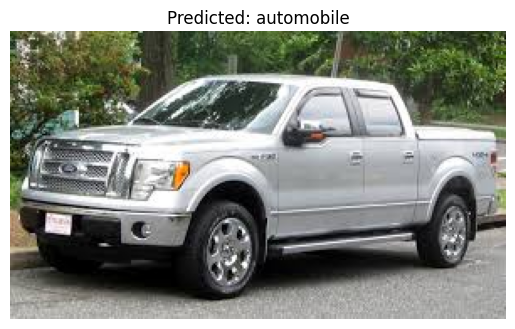

In [29]:
if __name__ == '__main__':
    select_and_predict()
